# Brassica rapa — Baseline Model Benchmarking: Aggregated Summary Table

**Purpose:** Loads the per-run `_metrics_summary.csv` files produced by `brassicaMLModels_eval_set.ipynb` across all six (PAIR × group_tag) configurations, assembles them into a single comparison table, displays it in-notebook, and exports a formatted Excel file and a flat CSV for manuscript use.

**Six configurations:**
- LF–MF1 (all gene pairs) and LF–MF1 Group I (arm–arm pairs only)
- LF–MF2 (all gene pairs) and LF–MF2 Group I (arm–arm pairs only)
- MF1–MF2 (all gene pairs) and MF1–MF2 Group I (arm–arm pairs only)

**Models evaluated:** Logistic Regression (LR), Support Vector Machine (SVM), Random Forest (RF), XGBoost (XGB) — all with default hyperparameters, evaluated by stratified 10-fold cross-validation on NaN-dropped datasets.

**Positive class:** WGD=1 (MF1 in LF–MF1; MF2 in LF–MF2 and MF1–MF2). Precision, Recall, and F1 are reported with respect to this class.

**To use:** Set `BRASSICA_EVAL_DIR` and `OUTPUT_DIR` in the configuration cell, then run all cells.

In [1]:
# ============================================================
# CONFIGURATION
# BRASSICA_EVAL_DIR : directory containing all per-run
#                     _metrics_summary.csv files produced by
#                     brassicaMLModels_eval_set.ipynb.
# OUTPUT_DIR        : where the final Excel and CSV are saved.
#                     Can be the same as BRASSICA_EVAL_DIR.
# ============================================================

from pathlib import Path

BRASSICA_EVAL_DIR = Path("../brassica_outputs/eval_set")
OUTPUT_DIR = BRASSICA_EVAL_DIR

OUTPUT_EXCEL = OUTPUT_DIR / "brassica_benchmarking_summary.xlsx"
OUTPUT_CSV   = OUTPUT_DIR / "brassica_benchmarking_summary.csv"

RUN_CONFIGS = [
    ("eval_lf_mf1_all",     "LF-MF1"),
    ("eval_lf_mf1_groupI",  "LF-MF1 Group I"),
    ("eval_lf_mf2_all",     "LF-MF2"),
    ("eval_lf_mf2_groupI",  "LF-MF2 Group I"),
    ("eval_mf1_mf2_all",    "MF1-MF2"),
    ("eval_mf1_mf2_groupI", "MF1-MF2 Group I"),
]

MODEL_DISPLAY = {"logreg": "LR", "svm": "SVM", "rf": "RF", "xgb": "XGB"}
MODEL_ORDER = ["logreg", "svm", "rf", "xgb"]


In [2]:
# ============================================================
# IMPORTS
# ============================================================

import pandas as pd
from IPython.display import display
from openpyxl import Workbook
from openpyxl.styles import Alignment, Border, Font, PatternFill, Side
from openpyxl.utils import get_column_letter

In [3]:
# ============================================================
# LOAD AND ASSEMBLE METRICS FROM ALL RUN CSVs
#
# Each _metrics_summary.csv has one row per model (4 rows).
# We load all 6 CSVs, enforce MODEL_ORDER within each, and
# stack into one summary_table (24 rows total).
#
# Columns pulled from each CSV:
#   abbrev           : model abbreviation key
#   f1_mean, f1_std  : mean and std of per-fold F1 (10 folds)
#   f1_pooled        : F1 on all predictions concatenated across folds
#   precision_pooled : pooled precision (positive class = WGD=1)
#   recall_pooled    : pooled recall
#   accuracy_pooled  : pooled accuracy
#   auc_pooled       : ROC AUC on pooled predictions
# ============================================================

all_rows = []

for prefix, display_label in RUN_CONFIGS:

    csv_path = BRASSICA_EVAL_DIR / f"{prefix}_metrics_summary.csv"

    # Explicit check: fails loudly if a run CSV is missing
    assert csv_path.exists(), (
        f"Missing expected CSV: {csv_path}\n"
        f"Check that BRASSICA_EVAL_DIR is correct and all 6 runs are complete."
    )

    df = pd.read_csv(csv_path)

    # Enforce the display order of models within each comparison group
    df = df.set_index("abbrev").loc[MODEL_ORDER].reset_index()

    for _, row in df.iterrows():
        all_rows.append({
            "Model Comparison": display_label,
            "Model*":           MODEL_DISPLAY[row["abbrev"]],
            "F1 Mean ± Std":    f"{row['f1_mean']:.4f} ± {row['f1_std']:.4f}",
            "F1 Pooled":        round(row["f1_pooled"],        4),
            "Precision Pooled": round(row["precision_pooled"], 4),
            "Recall Pooled":    round(row["recall_pooled"],    4),
            "Accuracy Pooled":  round(row["accuracy_pooled"],  4),
            "AUC Pooled":       round(row["auc_pooled"],       4),
        })

summary_table = pd.DataFrame(all_rows)

print(f"Assembled: {len(summary_table)} rows x {len(summary_table.columns)} columns")
print(f"Groups   : {summary_table['Model Comparison'].unique().tolist()}")


Assembled: 24 rows x 8 columns
Groups   : ['LF-MF1', 'LF-MF1 Group I', 'LF-MF2', 'LF-MF2 Group I', 'MF1-MF2', 'MF1-MF2 Group I']


In [4]:
# ============================================================
# DISPLAY TABLE IN NOTEBOOK
#
# "Model Comparison" label shown only on the first model row
# within each group, mirroring the merged-cell layout used
# in the exported Excel file.
# ============================================================

display_df = summary_table.copy()

# Suppress repeated "Model Comparison" labels within each group
is_first = display_df["Model Comparison"] != display_df["Model Comparison"].shift()
display_df.loc[~is_first, "Model Comparison"] = ""

# Style: header in dark blue/white; bold Model Comparison column
styled = (
    display_df.reset_index(drop=True)
    .style
    .set_properties(
        subset=["Model Comparison"],
        **{"font-weight": "bold"}
    )
    .set_table_styles([{
        "selector": "th",
        "props": [
            ("background-color", "#2F5597"),
            ("color",            "white"),
            ("font-weight",      "bold"),
            ("text-align",       "center"),
        ]
    }])
    .hide(axis="index")
)

display(styled)


Model Comparison,Model*,F1 Mean ± Std,F1 Pooled,Precision Pooled,Recall Pooled,Accuracy Pooled,AUC Pooled
LF-MF1,LR,0.5557 ± 0.0263,0.556000,0.566200,0.546200,0.565500,0.593500
,SVM,0.5597 ± 0.0291,0.560100,0.579900,0.541500,0.576200,0.601700
,RF,0.5977 ± 0.0195,0.597800,0.622400,0.575100,0.614500,0.678200
,XGB,0.6818 ± 0.0256,0.681800,0.679300,0.684300,0.681800,0.759700
LF-MF1 Group I,LR,0.5595 ± 0.0166,0.559800,0.554900,0.564900,0.557500,0.580300
,SVM,0.5531 ± 0.0153,0.553200,0.572300,0.535400,0.569200,0.584800
,RF,0.6183 ± 0.0309,0.618600,0.641000,0.597800,0.632900,0.694100
,XGB,0.6726 ± 0.0215,0.672900,0.666300,0.679600,0.670900,0.747700
LF-MF2,LR,0.5681 ± 0.0225,0.568200,0.591300,0.546800,0.585700,0.629600
,SVM,0.5910 ± 0.0224,0.591000,0.596700,0.585500,0.596100,0.636300


In [5]:
# ============================================================
# EXPORT: FORMATTED EXCEL AND FLAT CSV
#
# Excel layout:
#   Row 1    : header row — dark blue (#2F5597) background,
#              white bold Arial text
#   Rows 2+  : data rows — alternating light blue (#D9E8F5) /
#              white (#FFFFFF) background by comparison group
#   Column A : "Model Comparison" cells merged vertically
#              across the 4 model rows per group; centered, bold
#   All cells: thin border, Arial 10pt
#   Row 1    : frozen for scrolling
# ============================================================

# --- Style constants ---

HEADER_FILL  = PatternFill("solid", fgColor="2F5597")   # dark blue
HEADER_FONT  = Font(bold=True, color="FFFFFF", name="Arial", size=10)

# Odd-indexed groups (0, 2, 4) = light blue; even (1, 3, 5) = white
GROUP_FILLS = [
    PatternFill("solid", fgColor="D9E8F5"),   # light blue
    PatternFill("solid", fgColor="FFFFFF"),   # white
]

DATA_FONT    = Font(name="Arial", size=10)
BOLD_FONT    = Font(name="Arial", size=10, bold=True)
CENTER_ALIGN = Alignment(horizontal="center", vertical="center", wrap_text=True)
THIN_SIDE    = Side(style="thin")
THIN_BORDER  = Border(
    left=THIN_SIDE, right=THIN_SIDE,
    top=THIN_SIDE,  bottom=THIN_SIDE,
)

# Column display names paired with column widths (characters)
COLUMNS = [
    ("Model Comparison", 22),
    ("Model*",            9),
    ("F1 Mean ± Std",    21),
    ("F1 Pooled",         13),
    ("Precision Pooled",  17),
    ("Recall Pooled",     15),
    ("Accuracy Pooled",   17),
    ("AUC Pooled",        13),
]
COL_NAMES = [c[0] for c in COLUMNS]

# --- Build workbook ---
wb = Workbook()
ws = wb.active
ws.title = "Benchmarking Summary"

# Header row
for col_idx, (col_name, _) in enumerate(COLUMNS, start=1):
    cell           = ws.cell(row=1, column=col_idx, value=col_name)
    cell.font      = HEADER_FONT
    cell.fill      = HEADER_FILL
    cell.alignment = CENTER_ALIGN
    cell.border    = THIN_BORDER

ws.row_dimensions[1].height = 28   # slightly taller header

# Data rows
n_models = len(MODEL_ORDER)   # 4 models per comparison group

for group_idx, (prefix, display_label) in enumerate(RUN_CONFIGS):

    group_fill      = GROUP_FILLS[group_idx % 2]
    start_excel_row = 2 + group_idx * n_models
    end_excel_row   = start_excel_row + n_models - 1

    group_rows = (
        summary_table[summary_table["Model Comparison"] == display_label]
        .reset_index(drop=True)
    )

    for model_idx, (_, data_row) in enumerate(group_rows.iterrows()):
        excel_row = start_excel_row + model_idx

        for col_idx, (col_name, _) in enumerate(COLUMNS, start=1):

            cell        = ws.cell(row=excel_row, column=col_idx)
            cell.fill   = group_fill
            cell.border = THIN_BORDER

            if col_name == "Model Comparison":
                # Only write the label on the first row; the merge handles display
                cell.value     = display_label if model_idx == 0 else None
                cell.font      = BOLD_FONT
                cell.alignment = CENTER_ALIGN
            else:
                cell.value     = data_row[col_name]
                cell.font      = DATA_FONT
                cell.alignment = CENTER_ALIGN

    # Merge "Model Comparison" column (A) vertically across all 4 model rows
    ws.merge_cells(f"A{start_excel_row}:A{end_excel_row}")

    # openpyxl requires re-applying style to the merged cell object after merge
    merged_cell           = ws[f"A{start_excel_row}"]
    merged_cell.font      = BOLD_FONT
    merged_cell.fill      = group_fill
    merged_cell.alignment = CENTER_ALIGN
    merged_cell.border    = THIN_BORDER

# Set column widths
for col_idx, (_, width) in enumerate(COLUMNS, start=1):
    ws.column_dimensions[get_column_letter(col_idx)].width = width

# Freeze header row so it stays visible when scrolling
ws.freeze_panes = "A2"

# --- Save Excel ---
wb.save(OUTPUT_EXCEL)
print(f"Saved Excel : {OUTPUT_EXCEL}")

# --- Flat CSV (no merged cells; all 24 rows fully labeled) ---
summary_table.to_csv(OUTPUT_CSV, index=False)
print(f"Saved CSV   : {OUTPUT_CSV}")


Saved Excel : /blue/meixiazhao/laylaaschuster/brapaGDM/final_models/eval_set/brassica_benchmarking_summary.xlsx
Saved CSV   : /blue/meixiazhao/laylaaschuster/brapaGDM/final_models/eval_set/brassica_benchmarking_summary.csv


Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_models/eval_set/brassica_benchmarking_significance.png


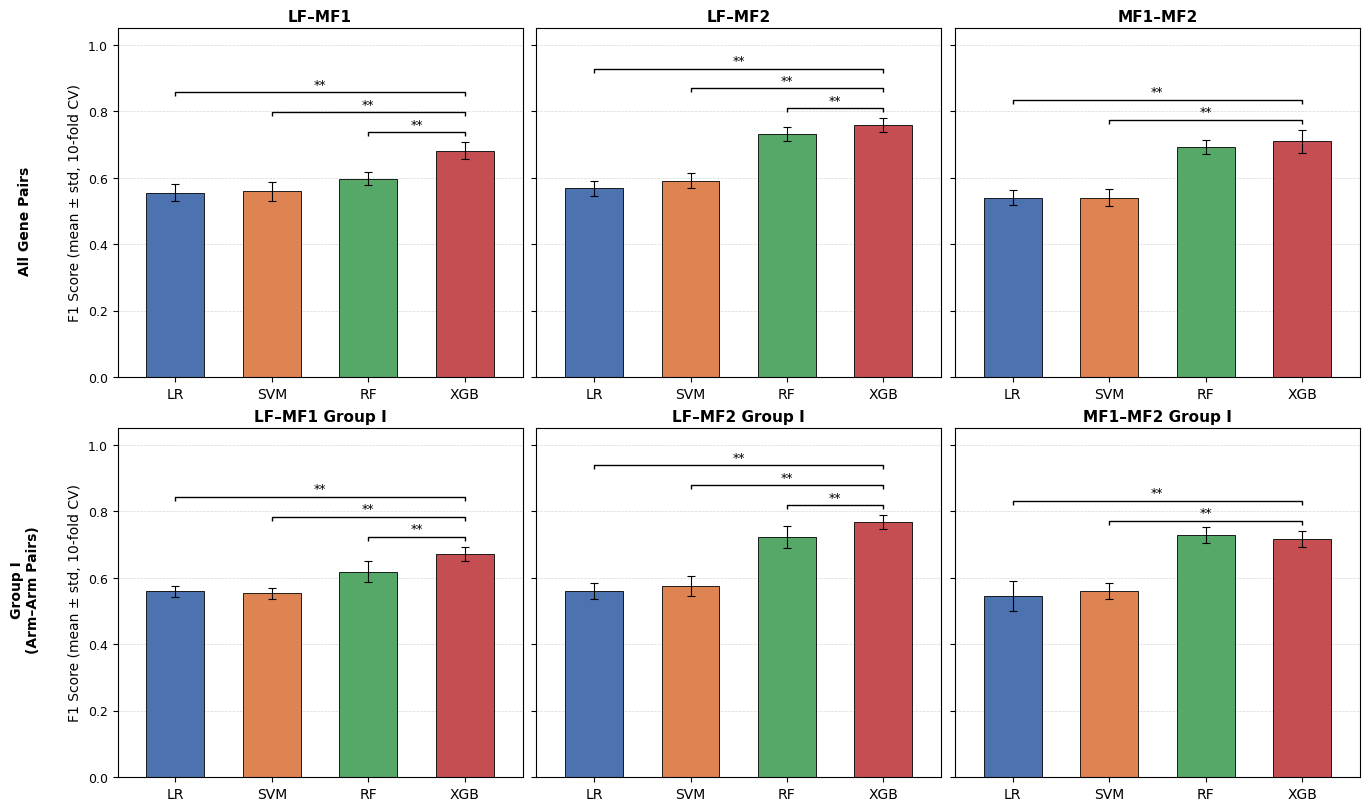

In [9]:
# ============================================================
# SIGNIFICANCE TESTING + BAR CHART
#
# For each comparison group: loads per-fold F1 scores for all
# four architectures, runs three Wilcoxon signed-rank tests
# (LR vs XGB, SVM vs XGB, RF vs XGB), applies Benjamini-
# Hochberg FDR correction within each group independently,
# and draws significance brackets only for p_adj < SIG_ALPHA.
#
# Note: with n=10 folds, the minimum achievable Wilcoxon
# p-value is 1/2^10 ≈ 0.001, so *** requires a perfectly
# one-directional difference across all 10 folds.
#
# Brackets are stacked by span width (narrowest = lowest),
# which places RF vs XGB lowest, SVM vs XGB middle, and
# LR vs XGB highest when all three are significant.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

# ============================================================
# TUNABLE PARAMETERS
# ============================================================

# Per-fold F1 files live in the same directory as the summary CSVs
FOLD_F1_DIR = BRASSICA_EVAL_DIR

# Colors for each architecture (colorblind-contrasting)
MODEL_COLORS = {
    "logreg": "#4C72B0",   # muted blue
    "svm":    "#DD8452",   # muted orange
    "rf":     "#55A868",   # muted green
    "xgb":    "#C44E52",   # muted red
}

# Significance threshold applied to FDR-corrected p-values
SIG_ALPHA = 0.05

# Bar styling
BAR_WIDTH  = 0.6
EDGE_COLOR = "black"
EDGE_WIDTH = 0.6
ERROR_KW   = dict(ecolor="black", capsize=3, capthick=0.8, elinewidth=0.8)

# Bracket geometry (in data / axis units)
BRACKET_GAP  = 0.03    # clearance above the tallest error bar before first bracket
BRACKET_STEP = 0.06    # vertical distance between stacked brackets
BRACKET_DROP = 0.012   # length of the vertical tick at each bracket end
BRACKET_LW   = 1.0     # bracket line width
BRACKET_FS   = 9       # significance symbol font size

# 2 x 3 grid layout
# Row 0 = all gene pairs; row 1 = Group I (arm-arm pairs only)
# Columns = LF-MF1, LF-MF2, MF1-MF2
GRID_LAYOUT = [
    [("eval_lf_mf1_all",     "LF\u2013MF1"),
     ("eval_lf_mf2_all",     "LF\u2013MF2"),
     ("eval_mf1_mf2_all",    "MF1\u2013MF2")],
    [("eval_lf_mf1_groupI",  "LF\u2013MF1 Group I"),
     ("eval_lf_mf2_groupI",  "LF\u2013MF2 Group I"),
     ("eval_mf1_mf2_groupI", "MF1\u2013MF2 Group I")],
]

# Output path for the saved figure
FIG_SIG_PATH = OUTPUT_DIR / "brassica_benchmarking_significance.png"

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def p_to_symbol(p):
    """Convert a p-value to a standard significance symbol."""
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return "ns"


def draw_bracket(ax, x1, x2, y_base, symbol):
    """
    Draw a significance bracket between bar positions x1 and x2.

    The horizontal bar sits at y_base; vertical drops extend
    downward by BRACKET_DROP. The symbol is placed just above
    the midpoint of the horizontal bar.
    """
    ax.plot(
        [x1, x1, x2, x2],
        [y_base - BRACKET_DROP, y_base, y_base, y_base - BRACKET_DROP],
        lw=BRACKET_LW, color="black", solid_capstyle="butt",
        zorder=3,
    )
    ax.text(
        (x1 + x2) / 2, y_base + 0.004, symbol,
        ha="center", va="bottom",
        fontsize=BRACKET_FS, color="black", zorder=3,
    )


# ============================================================
# MAIN: LOAD DATA, TEST, PLOT
# ============================================================

fig, axes = plt.subplots(
    2, 3,
    figsize=(13, 8),
    sharey=True,
    constrained_layout=True,
)

x_positions = np.arange(len(MODEL_ORDER))   # [0, 1, 2, 3]
xgb_pos     = MODEL_ORDER.index("xgb")      # 3
baselines   = [m for m in MODEL_ORDER if m != "xgb"]   # [logreg, svm, rf]

for row_idx, row_configs in enumerate(GRID_LAYOUT):
    for col_idx, (prefix, title) in enumerate(row_configs):

        ax = axes[row_idx, col_idx]

        # --- Load per-fold F1 scores for each architecture ---
        fold_f1 = {}   # abbrev -> np.array, shape (10,)
        means   = {}   # abbrev -> float
        stds    = {}   # abbrev -> float

        for abbrev in MODEL_ORDER:
            fpath = FOLD_F1_DIR / f"{prefix}_{abbrev}_fold_f1.csv"
            assert fpath.exists(), (
                f"Missing fold F1 file:\n  {fpath}\n"
                f"Check FOLD_F1_DIR and that all eval runs are complete."
            )
            scores          = pd.read_csv(fpath)["f1"].values
            fold_f1[abbrev] = scores
            means[abbrev]   = scores.mean()
            stds[abbrev]    = scores.std()   # ddof=0, consistent with eval notebook

        # --- Wilcoxon signed-rank tests (two-sided): each baseline vs XGB ---
        raw_pvals = []
        for baseline in baselines:
            diffs = fold_f1[baseline] - fold_f1["xgb"]
            if np.all(diffs == 0):
                # All fold differences are zero: test undefined; assign p=1
                raw_pvals.append(1.0)
            else:
                _, p = wilcoxon(
                    fold_f1[baseline], fold_f1["xgb"],
                    alternative="two-sided",
                )
                raw_pvals.append(p)

        # FDR correction (Benjamini-Hochberg) within this group only
        # 3 tests per group: LR vs XGB, SVM vs XGB, RF vs XGB
        _, p_adj, _, _ = multipletests(raw_pvals, method="fdr_bh")

        # --- Draw bars ---
        for x_pos, abbrev in zip(x_positions, MODEL_ORDER):
            ax.bar(
                x_pos,
                means[abbrev],
                width=BAR_WIDTH,
                color=MODEL_COLORS[abbrev],
                edgecolor=EDGE_COLOR,
                linewidth=EDGE_WIDTH,
                yerr=stds[abbrev],
                error_kw=ERROR_KW,
                zorder=2,
            )

        # --- Draw significance brackets for p_adj < SIG_ALPHA ---
        # Collect significant comparisons and sort by span (narrowest first
        # so the lowest bracket is always the shortest span)
        sig_comparisons = []
        for baseline, p in zip(baselines, p_adj):
            if p < SIG_ALPHA:
                b_pos = MODEL_ORDER.index(baseline)
                sig_comparisons.append((b_pos, xgb_pos, p))

        sig_comparisons.sort(key=lambda c: c[1] - c[0])

        for bracket_idx, (x1, x2, p) in enumerate(sig_comparisons):
            # Bracket clears the top of the error bar for both compared bars
            y_base = (
                max(
                    means[MODEL_ORDER[x1]] + stds[MODEL_ORDER[x1]],
                    means[MODEL_ORDER[x2]] + stds[MODEL_ORDER[x2]],
                )
                + BRACKET_GAP
                + bracket_idx * BRACKET_STEP
            )
            draw_bracket(ax, x1, x2, y_base, p_to_symbol(p))

        # --- Axis formatting ---
        ax.set_title(title, fontsize=11, fontweight="bold", pad=5)
        ax.set_xticks(x_positions)
        ax.set_xticklabels(
            [MODEL_DISPLAY[a] for a in MODEL_ORDER], fontsize=10
        )
        ax.set_xlim(-0.6, len(MODEL_ORDER) - 0.4)

        # Shared y-axis: 0 to 1.05 with ticks only at 0–1.0
        ax.set_ylim(0, 1.05)
        ax.yaxis.set_major_locator(
            ticker.FixedLocator([0, 0.2, 0.4, 0.6, 0.8, 1.0])
        )
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
        ax.tick_params(axis="y", labelsize=9)

        # Subtle horizontal gridlines behind bars
        ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5, zorder=0)
        ax.set_axisbelow(True)

        # Y-axis label only on leftmost column
        if col_idx == 0:
            ax.set_ylabel("F1 Score (mean \u00b1 std, 10-fold CV)", fontsize=10)

# Row labels in the left margin, rotated
fig.text(
    -0.03, 0.73, "All Gene Pairs",
    va="center", ha="center", fontsize=10, fontweight="bold", rotation=90,
)
fig.text(
    -0.03, 0.27, "Group I\n(Arm\u2013Arm Pairs)",
    va="center", ha="center", fontsize=10, fontweight="bold", rotation=90,
)

# ============================================================
# SAVE
# ============================================================

plt.savefig(FIG_SIG_PATH, dpi=600, bbox_inches="tight")
print(f"Saved: {FIG_SIG_PATH}")
plt.show()